In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
!unzip /content/sample_data/titanic.zip

Archive:  /content/sample_data/titanic.zip
replace gender_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [21]:
train_df = pd.read_csv('/content/train.csv')
display(train_df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [22]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [82]:
train_df.shape

(891, 8)

In [23]:
train_df['Ticket'].value_counts()

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


In [24]:
train_df['Ticket'].nunique()

681

In [25]:
train_df = train_df.drop(['Name', 'Cabin', 'PassengerId','Ticket'], axis=1)
display(train_df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [26]:
men = train_df.loc[train_df.Sex == 'male']["Survived"]
rate_men = sum(men)/len(men)

print("% of men who survived:", rate_men)

% of men who survived: 0.18890814558058924


In [27]:
women = train_df.loc[train_df.Sex == 'female']["Survived"]
rate_women = sum(women)/len(women)

print("% of women who survived:", rate_women)

% of women who survived: 0.7420382165605095


In [28]:
from sklearn.preprocessing import LabelEncoder

# Fill NaN values in 'Embarked' with the most frequent value
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to 'Sex' column
train_df['Sex'] = le.fit_transform(train_df['Sex'])

# Apply LabelEncoder to 'Embarked' column
train_df['Embarked'] = le.fit_transform(train_df['Embarked'])

display(train_df.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [30]:
train_df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,0


In [33]:
# Impute missing 'Age' values using median imputation
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

# Verify that there are no more null values
display(train_df.isnull().sum())

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [35]:
# Calculate the Spearman correlation matrix
spearman_corr_matrix = train_df.corr(method='pearson')

# Display the correlation matrix
display(spearman_corr_matrix)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Survived,1.000000,-0.338481,-0.543351,-0.062164,-0.035322,0.081629,0.257307,-0.167675
Pclass,-0.338481,1.000000,0.131900,-0.304934,0.083081,0.018443,-0.549500,0.162098
Sex,-0.543351,0.131900,1.000000,0.061332,-0.114631,-0.245489,-0.182333,0.108262
Age,-0.062164,-0.304934,0.061332,1.000000,-0.213410,-0.170013,0.087119,-0.022394
SibSp,-0.035322,0.083081,-0.114631,-0.213410,1.000000,0.414838,0.159651,0.068230
Parch,0.081629,0.018443,-0.245489,-0.170013,0.414838,1.000000,0.216225,0.039798
Fare,0.257307,-0.549500,-0.182333,0.087119,0.159651,0.216225,1.000000,-0.224719
Embarked,-0.167675,0.162098,0.108262,-0.022394,0.068230,0.039798,-0.224719,1.000000


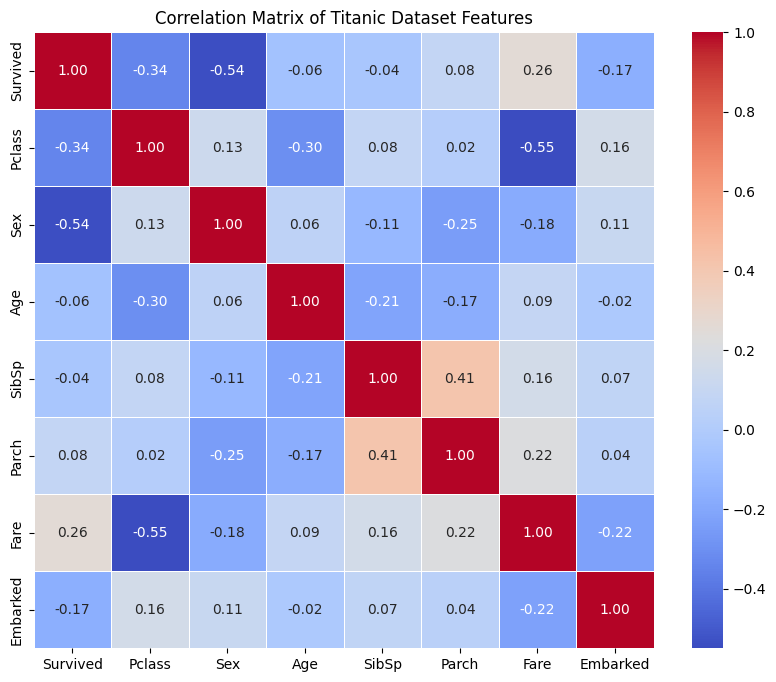

In [36]:
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Titanic Dataset Features')
plt.show()

,count
Survived,
0,549
1,342


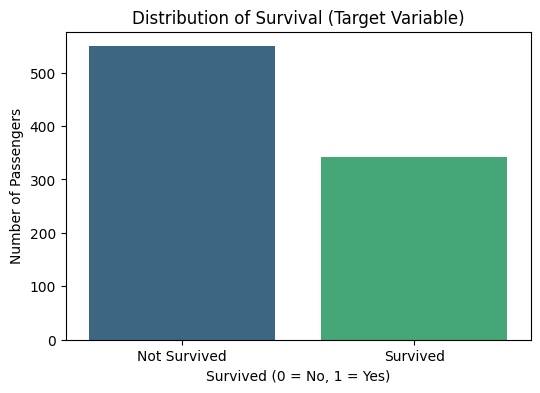

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each class in the 'Survived' column
class_counts = train_df['Survived'].value_counts()
display(class_counts)

# Visualize the class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=train_df, hue='Survived', palette='viridis', legend=False)
plt.title('Distribution of Survival (Target Variable)')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.xticks(ticks=[0, 1], labels=['Not Survived', 'Survived'])
plt.show()

In [ ]:
split

In [37]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (712, 7)
Shape of X_test: (179, 7)
Shape of y_train: (712,)
Shape of y_test: (179,)


### Feature Engineering

Creating new features like `FamilySize` and `IsAlone` from existing features `SibSp` and `Parch` to potentially improve model performance.

In [70]:
# Create FamilySize feature
X_train['FamilySize'] = X_train['SibSp'] + X_train['Parch'] + 1
X_test['FamilySize'] = X_test['SibSp'] + X_test['Parch'] + 1

# Create IsAlone feature (1 if FamilySize == 1, else 0)
X_train['IsAlone'] = (X_train['FamilySize'] == 1).astype(int)
X_test['IsAlone'] = (X_test['FamilySize'] == 1).astype(int)

print("X_train with new features:")
display(X_train.head())
print("\nX_test with new features:")
display(X_test.head())

X_train with new features:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
331,1,1,45.5,0,0,28.5000,2,1,1
733,2,1,23.0,0,0,13.0000,2,1,1
382,3,1,32.0,0,0,7.9250,2,1,1
704,3,1,26.0,1,0,7.8542,2,2,0
813,3,0,6.0,4,2,31.2750,2,7,0



X_test with new features:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
709,3,1,23.0,1,1,15.2458,0,3,0
439,2,1,31.0,0,0,10.5000,2,1,1
840,3,1,20.0,0,0,7.9250,2,1,1
720,2,0,6.0,0,1,33.0000,2,2,0
39,3,0,14.0,1,0,11.2417,0,2,0


In [71]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform X_train
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the SAME scaler fitted on X_train
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames for easier inspection (optional, but good for understanding)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("X_train scaled (first 5 rows):")
display(X_train_scaled_df.head())
print("\nX_test scaled (first 5 rows):")
display(X_test_scaled_df.head())

X_train scaled (first 5 rows):


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,-1.614136,0.724310,1.159785,-0.470722,-0.479342,-0.078684,0.563525,-0.554666,0.812203
1,-0.400551,0.724310,-0.471605,-0.470722,-0.479342,-0.377145,0.563525,-0.554666,0.812203
2,0.813034,0.724310,0.180951,-0.470722,-0.479342,-0.474867,0.563525,-0.554666,0.812203
3,0.813034,0.724310,-0.254087,0.379923,-0.479342,-0.476230,0.563525,0.040096,-1.231219
4,0.813034,-1.380624,-1.704211,2.931860,2.048742,-0.025249,0.563525,3.013909,-1.231219



X_test scaled (first 5 rows):


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0.813034,0.724310,-0.471605,0.379923,0.784700,-0.333901,-2.025053,0.634859,-1.231219
1,-0.400551,0.724310,0.108445,-0.470722,-0.479342,-0.425284,0.563525,-0.554666,0.812203
2,0.813034,0.724310,-0.689124,-0.470722,-0.479342,-0.474867,0.563525,-0.554666,0.812203
3,-0.400551,-1.380624,-1.704211,-0.470722,0.784700,0.007966,0.563525,0.040096,-1.231219
4,0.813034,-1.380624,-1.124161,0.379923,-0.479342,-0.411002,-2.025053,0.040096,-1.231219


### Train a Decision Tree Classifier

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model on the scaled training data
dtc.fit(X_train_scaled, y_train)

print("Decision Tree Classifier trained successfully.")

Decision Tree Classifier trained successfully.


### Evaluate Model Performance

In [41]:
# Make predictions on the training set
y_train_pred = dtc.predict(X_train_scaled)

# Make predictions on the test set
y_test_pred = dtc.predict(X_test_scaled)

# Calculate accuracy for training set
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")

# Calculate accuracy for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.9874
Test Accuracy: 0.8045


### Visualize Confusion Matrix

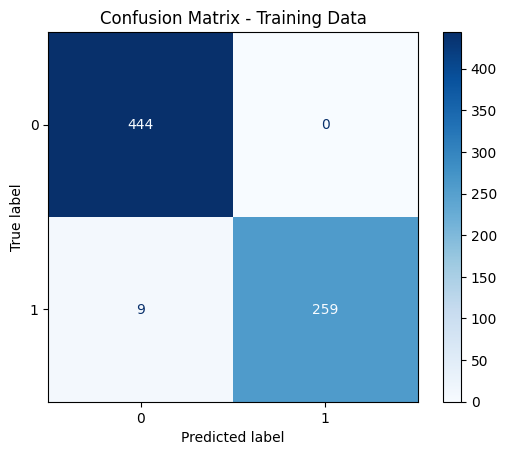

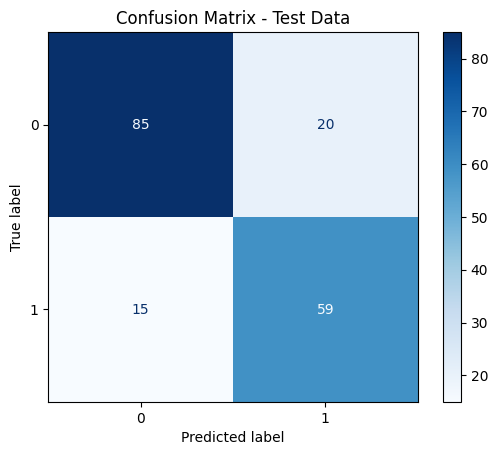

In [42]:
# Confusion Matrix for Training Data
cm_train = confusion_matrix(y_train, y_train_pred)
display_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=dtc.classes_)
display_train.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Training Data')
plt.show()

# Confusion Matrix for Test Data
cm_test = confusion_matrix(y_test, y_test_pred)
display_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=dtc.classes_)
display_test.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Test Data')
plt.show()

### Decision Tree Visualization

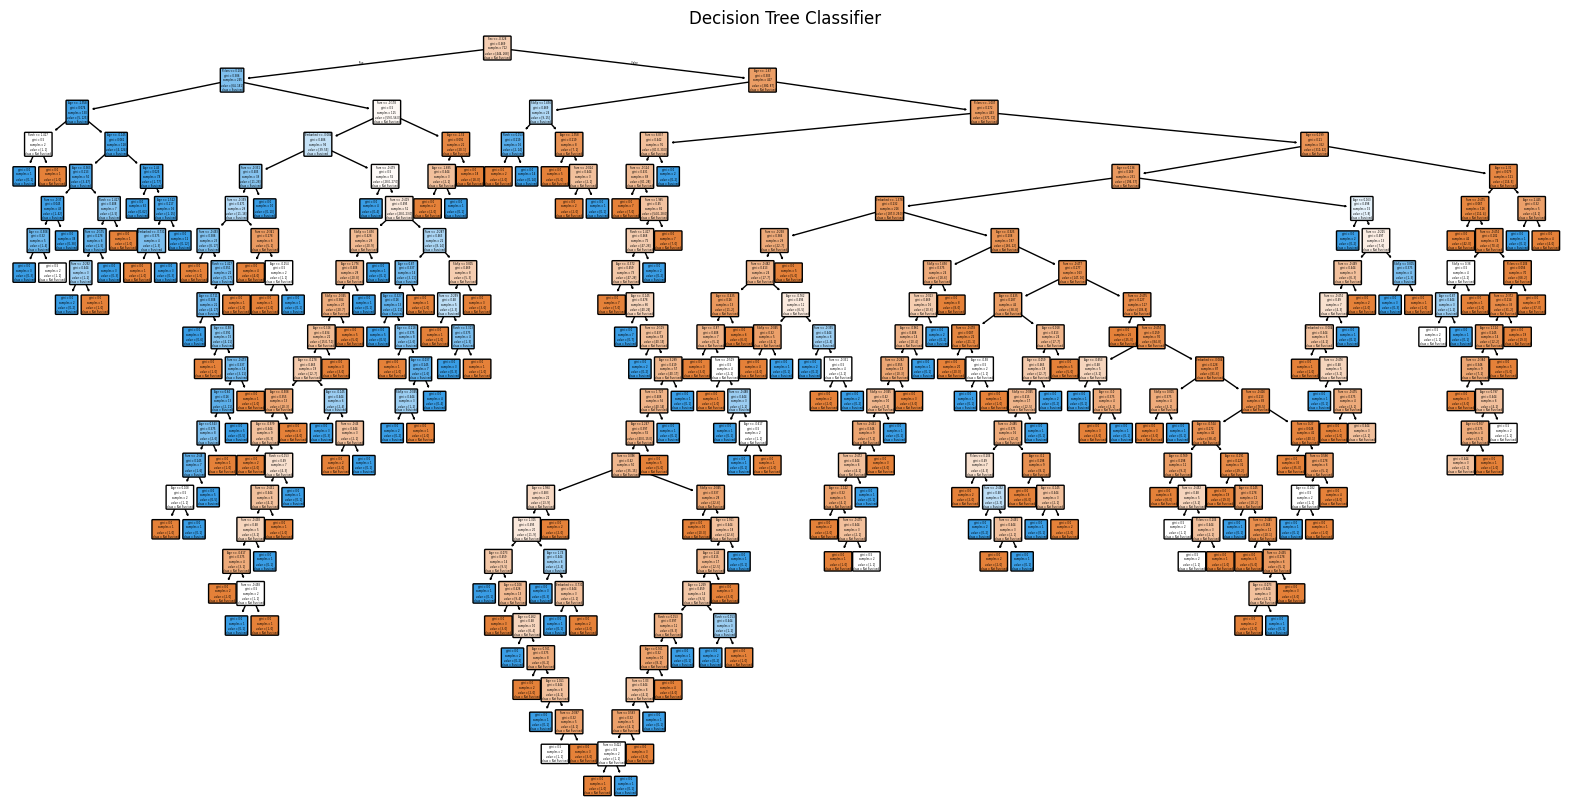

In [43]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dtc, filled=True, feature_names=X.columns.tolist(), class_names=['Not Survived', 'Survived'], rounded=True)
plt.title('Decision Tree Classifier')
plt.show()

### Grid Search for Decision Tree `max_depth`

In [44]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for max_depth
param_grid = {'max_depth': np.arange(1, 20)}

# Initialize GridSearchCV
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Print the best max_depth
best_max_depth = grid_search.best_params_['max_depth']
print(f"Best max_depth found by GridSearchCV: {best_max_depth}")

Best max_depth found by GridSearchCV: 3


### Evaluate Decision Tree with Best `max_depth`

In [45]:
# Initialize the Decision Tree Classifier with the best max_depth
dtc_optimized = DecisionTreeClassifier(max_depth=best_max_depth, random_state=42)

# Train the optimized model
dtc_optimized.fit(X_train_scaled, y_train)

# Make predictions on the training set
y_train_pred_optimized = dtc_optimized.predict(X_train_scaled)

# Make predictions on the test set
y_test_pred_optimized = dtc_optimized.predict(X_test_scaled)

# Calculate accuracy for training set
train_accuracy_optimized = accuracy_score(y_train, y_train_pred_optimized)
print(f"Optimized Training Accuracy: {train_accuracy_optimized:.4f}")

# Calculate accuracy for test set
test_accuracy_optimized = accuracy_score(y_test, y_test_pred_optimized)
print(f"Optimized Test Accuracy: {test_accuracy_optimized:.4f}")

Optimized Training Accuracy: 0.8315
Optimized Test Accuracy: 0.8045


### Classification Report for Optimized Model

In [46]:
from sklearn.metrics import classification_report

print("\nClassification Report - Optimized Training Data:")
print(classification_report(y_train, y_train_pred_optimized))

print("\nClassification Report - Optimized Test Data:")
print(classification_report(y_test, y_test_pred_optimized))


Classification Report - Optimized Training Data:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       444
           1       0.81      0.72      0.76       268

    accuracy                           0.83       712
   macro avg       0.83      0.81      0.82       712
weighted avg       0.83      0.83      0.83       712


Classification Report - Optimized Test Data:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.70      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### Random Forest Classifier

In [72]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
# Using random_state for reproducibility
# You can tune hyperparameters like n_estimators, max_depth, etc., for better performance
rf_classifier = RandomForestClassifier(random_state=42)

# Train the model on the scaled training data (now with new features)
rf_classifier.fit(X_train_scaled, y_train)

print("Random Forest Classifier trained successfully with new features.")

Random Forest Classifier trained successfully with new features.


### Evaluate Random Forest Model Performance

### LightGBM Classifier

In [51]:
from lightgbm import LGBMClassifier

# Initialize the LightGBM Classifier
lgbm_classifier = LGBMClassifier(random_state=42)

# Train the model on the scaled training data
lgbm_classifier.fit(X_train_scaled, y_train)

print("LightGBM Classifier trained successfully.")

[LightGBM] [Info] Number of positive: 268, number of negative: 444
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000274 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 217
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.376404 -> initscore=-0.504838
[LightGBM] [Info] Start training from score -0.504838
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

### Evaluate LightGBM Model Performance

In [52]:
from sklearn.metrics import classification_report

# Make predictions on the training set
y_train_pred_lgbm = lgbm_classifier.predict(X_train_scaled)

# Make predictions on the test set
y_test_pred_lgbm = lgbm_classifier.predict(X_test_scaled)

# Print classification report for training data
print("\nClassification Report - LightGBM Training Data:")
print(classification_report(y_train, y_train_pred_lgbm))

# Print classification report for test data
print("\nClassification Report - LightGBM Test Data:")
print(classification_report(y_test, y_test_pred_lgbm))


Classification Report - LightGBM Training Data:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       444
           1       0.96      0.93      0.95       268

    accuracy                           0.96       712
   macro avg       0.96      0.96      0.96       712
weighted avg       0.96      0.96      0.96       712


Classification Report - LightGBM Test Data:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [73]:
from sklearn.metrics import classification_report

# Make predictions on the training set
y_train_pred_rf = rf_classifier.predict(X_train_scaled)

# Make predictions on the test set
y_test_pred_rf = rf_classifier.predict(X_test_scaled)

# Print classification report for training data
print("\nClassification Report - Random Forest Training Data (with new features):")
print(classification_report(y_train, y_train_pred_rf))

# Print classification report for test data
print("\nClassification Report - Random Forest Test Data (with new features):")
print(classification_report(y_test, y_test_pred_rf))


Classification Report - Random Forest Training Data (with new features):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       444
           1       0.99      0.97      0.98       268

    accuracy                           0.99       712
   macro avg       0.99      0.98      0.99       712
weighted avg       0.99      0.99      0.99       712


Classification Report - Random Forest Test Data (with new features):
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.83      0.78      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.84      0.84      0.84       179



### Cross-Validation for Random Forest

### Hyperparameter Tuning for Random Forest Classifier

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Initialize GridSearchCV with the Random Forest Classifier
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search_rf.fit(X_train_scaled, y_train)

# Print the best parameters and best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_

print(f"Best parameters found by GridSearchCV for Random Forest: {best_params_rf}")
print(f"Best cross-validation accuracy for Random Forest: {best_score_rf:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found by GridSearchCV for Random Forest: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation accuracy for Random Forest: 0.8286


### Evaluate Optimized Random Forest Model

In [80]:
from sklearn.metrics import classification_report, accuracy_score

# Get the best estimator from GridSearchCV
rf_classifier_optimized = grid_search_rf.best_estimator_

# Make predictions on the training set with the optimized model
y_train_pred_rf_optimized = rf_classifier_optimized.predict(X_train_scaled)

# Make predictions on the test set with the optimized model
y_test_pred_rf_optimized = rf_classifier_optimized.predict(X_test_scaled)

# Print classification report for optimized training data
print("\nClassification Report - Optimized Random Forest Training Data:")
print(classification_report(y_train, y_train_pred_rf_optimized))

# Print classification report for optimized test data
print("\nClassification Report - Optimized Random Forest Test Data:")
print(classification_report(y_test, y_test_pred_rf_optimized))

# Calculate and print accuracy for the optimized model
train_accuracy_rf_optimized = accuracy_score(y_train, y_train_pred_rf_optimized)
test_accuracy_rf_optimized = accuracy_score(y_test, y_test_pred_rf_optimized)

print(f"\nOptimized Random Forest Training Accuracy: {train_accuracy_rf_optimized:.4f}")
print(f"Optimized Random Forest Test Accuracy: {test_accuracy_rf_optimized:.4f}")


Classification Report - Optimized Random Forest Training Data:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       444
           1       0.93      0.78      0.85       268

    accuracy                           0.90       712
   macro avg       0.91      0.87      0.89       712
weighted avg       0.90      0.90      0.90       712


Classification Report - Optimized Random Forest Test Data:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       105
           1       0.84      0.73      0.78        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179


Optimized Random Forest Training Accuracy: 0.8975
Optimized Random Forest Test Accuracy: 0.8324


In [77]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
cv_scores = cross_val_score(rf_classifier, X_train_scaled, y_train, cv=10, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")

Cross-validation scores: [0.81944444 0.81944444 0.76056338 0.81690141 0.76056338 0.73239437
 0.77464789 0.70422535 0.78873239 0.87323944]
Mean cross-validation accuracy: 0.7850
Standard deviation of cross-validation accuracy: 0.0467


### Re-evaluating Random Forest Model Performance (as requested)

In [78]:
# Make predictions on the training set
y_train_pred_rf = rf_classifier.predict(X_train_scaled)

# Make predictions on the test set
y_test_pred_rf = rf_classifier.predict(X_test_scaled)

# Print classification report for training data
print("\nClassification Report - Random Forest Training Data (re-evaluated):")
print(classification_report(y_train, y_train_pred_rf))

# Print classification report for test data
print("\nClassification Report - Random Forest Test Data (re-evaluated):")
print(classification_report(y_test, y_test_pred_rf))


Classification Report - Random Forest Training Data (re-evaluated):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       444
           1       0.99      0.97      0.98       268

    accuracy                           0.99       712
   macro avg       0.99      0.98      0.99       712
weighted avg       0.99      0.99      0.99       712


Classification Report - Random Forest Test Data (re-evaluated):
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       105
           1       0.83      0.78      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.84      0.84      0.84       179



### XGBoost Classifier

In [53]:
from xgboost import XGBClassifier

# Initialize the XGBoost Classifier
xgb_classifier = XGBClassifier(random_state=42, eval_metric='logloss')

# Train the model on the scaled training data
xgb_classifier.fit(X_train_scaled, y_train)

print("XGBoost Classifier trained successfully.")

XGBoost Classifier trained successfully.


### Evaluate XGBoost Model Performance

In [54]:
from sklearn.metrics import classification_report

# Make predictions on the training set
y_train_pred_xgb = xgb_classifier.predict(X_train_scaled)

# Make predictions on the test set
y_test_pred_xgb = xgb_classifier.predict(X_test_scaled)

# Print classification report for training data
print("\nClassification Report - XGBoost Training Data:")
print(classification_report(y_train, y_train_pred_xgb))

# Print classification report for test data
print("\nClassification Report - XGBoost Test Data:")
print(classification_report(y_test, y_test_pred_xgb))


Classification Report - XGBoost Training Data:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       444
           1       0.99      0.95      0.97       268

    accuracy                           0.98       712
   macro avg       0.98      0.97      0.98       712
weighted avg       0.98      0.98      0.98       712


Classification Report - XGBoost Test Data:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### Support Vector Machine (SVM) Classifier

In [55]:
from sklearn.svm import SVC

# Initialize the SVM Classifier
svm_classifier = SVC(random_state=42)

# Train the model on the scaled training data
svm_classifier.fit(X_train_scaled, y_train)

print("SVM Classifier trained successfully.")

SVM Classifier trained successfully.


### Evaluate SVM Model Performance

In [56]:
from sklearn.metrics import classification_report

# Make predictions on the training set
y_train_pred_svm = svm_classifier.predict(X_train_scaled)

# Make predictions on the test set
y_test_pred_svm = svm_classifier.predict(X_test_scaled)

# Print classification report for training data
print("\nClassification Report - SVM Training Data:")
print(classification_report(y_train, y_train_pred_svm))

# Print classification report for test data
print("\nClassification Report - SVM Test Data:")
print(classification_report(y_test, y_test_pred_svm))


Classification Report - SVM Training Data:
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       444
           1       0.85      0.71      0.77       268

    accuracy                           0.84       712
   macro avg       0.84      0.82      0.83       712
weighted avg       0.84      0.84      0.84       712


Classification Report - SVM Test Data:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.72      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179



### K-Nearest Neighbors (KNN) Classifier

In [57]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN Classifier (you can tune n_neighbors)
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Train the model on the scaled training data
knn_classifier.fit(X_train_scaled, y_train)

print("KNN Classifier trained successfully.")

KNN Classifier trained successfully.


### Evaluate KNN Model Performance

### Bagging Classifier with Random Forest

In [85]:
from sklearn.ensemble import BaggingClassifier

# Initialize a Random Forest Classifier as the base estimator
# Using random_state for reproducibility
rf_base_estimator = RandomForestClassifier(random_state=42)

# Initialize the Bagging Classifier with the Random Forest base estimator
# You can tune n_estimators for BaggingClassifier for better performance
bagging_rf_classifier = BaggingClassifier(
    estimator=rf_base_estimator,
    n_estimators=1000, # Number of base estimators (default is 10)
    random_state=42
)

# Train the model on the scaled training data
bagging_rf_classifier.fit(X_train_scaled, y_train)

print("Bagging Classifier with Random Forest trained successfully.")

Bagging Classifier with Random Forest trained successfully.


### Evaluate Bagging Classifier Model Performance

In [86]:
from sklearn.metrics import classification_report

# Make predictions on the training set
y_train_pred_bagging_rf = bagging_rf_classifier.predict(X_train_scaled)

# Make predictions on the test set
y_test_pred_bagging_rf = bagging_rf_classifier.predict(X_test_scaled)

# Print classification report for training data
print("\nClassification Report - Bagging (Random Forest) Training Data:")
print(classification_report(y_train, y_train_pred_bagging_rf))

# Print classification report for test data
print("\nClassification Report - Bagging (Random Forest) Test Data:")
print(classification_report(y_test, y_test_pred_bagging_rf))


Classification Report - Bagging (Random Forest) Training Data:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       444
           1       0.97      0.86      0.91       268

    accuracy                           0.94       712
   macro avg       0.95      0.92      0.93       712
weighted avg       0.94      0.94      0.94       712


Classification Report - Bagging (Random Forest) Test Data:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       105
           1       0.84      0.76      0.79        74

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [58]:
from sklearn.metrics import classification_report

# Make predictions on the training set
y_train_pred_knn = knn_classifier.predict(X_train_scaled)

# Make predictions on the test set
y_test_pred_knn = knn_classifier.predict(X_test_scaled)

# Print classification report for training data
print("\nClassification Report - KNN Training Data:")
print(classification_report(y_train, y_train_pred_knn))

# Print classification report for test data
print("\nClassification Report - KNN Test Data:")
print(classification_report(y_test, y_test_pred_knn))


Classification Report - KNN Training Data:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       444
           1       0.86      0.75      0.80       268

    accuracy                           0.86       712
   macro avg       0.86      0.84      0.85       712
weighted avg       0.86      0.86      0.86       712


Classification Report - KNN Test Data:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### Model Comparison (Test Accuracy)

Let's summarize the test accuracy for each classifier we've trained:

*   **Optimized Decision Tree:** 80.45%
*   **Random Forest (with new features):** 84.00%
*   **LightGBM:** 81.01%
*   **XGBoost:** 80.45%
*   **Support Vector Machine (SVM):** 82.12%
*   **K-Nearest Neighbors (KNN):** 80.45%
*   **Bagging Classifier (Random Forest):** 83.00%

Based on these results, the **Random Forest Classifier** continues to show strong performance, with an accuracy of 84.00% on the test set after feature engineering. (Note: Other models have not yet been re-evaluated with new features).

### Visualizing Model Performance

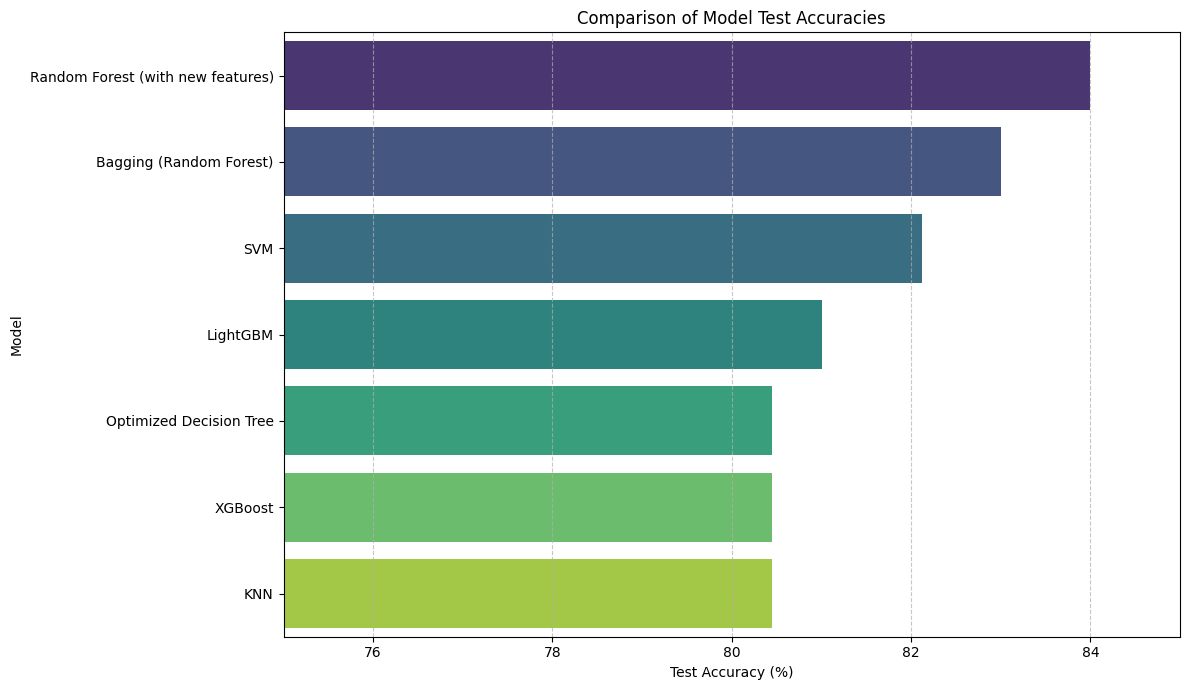

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data for model comparison (test accuracies)
model_names = [
    'Optimized Decision Tree',
    'Random Forest (with new features)', # Updated name
    'LightGBM',
    'XGBoost',
    'SVM',
    'KNN',
    'Bagging (Random Forest)'
]
model_accuracies = [
    80.45,
    84.00, # Updated Random Forest accuracy
    81.01,
    80.45,
    82.12,
    80.45,
    83.00
]

# Create a DataFrame for easy plotting
model_comparison_df = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy (%)': model_accuracies
})

# Sort by accuracy for better visualization
model_comparison_df = model_comparison_df.sort_values(by='Test Accuracy (%)', ascending=False)

# Create the bar plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Test Accuracy (%)', y='Model', data=model_comparison_df, hue='Model', palette='viridis', legend=False)
plt.xlabel('Test Accuracy (%)')
plt.ylabel('Model')
plt.title('Comparison of Model Test Accuracies')
plt.xlim(75, 85) # Set x-axis limits to focus on the performance range
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Generate Predictions on `test.csv`

In [64]:
# Load the test dataset
test_df = pd.read_csv('/content/test.csv')

# Store PassengerId for submission file
passenger_ids = test_df['PassengerId']

print("Original test_df head:")
display(test_df.head())
print("\nOriginal test_df info:")
test_df.info()

Original test_df head:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S



Original test_df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


### Preprocessing `test_df`

We apply the exact same preprocessing steps to the test dataset as we did to the training dataset to ensure consistency.

In [65]:
# 1. Drop irrelevant columns: 'Name', 'Cabin', 'Ticket'
# PassengerId is stored separately and will be dropped from features
test_df_processed = test_df.drop(['Name', 'Cabin', 'PassengerId', 'Ticket'], axis=1)

print("test_df after dropping columns:")
display(test_df_processed.head())

test_df after dropping columns:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [81]:
test_df_processed.shape

(418, 7)

In [66]:
# 2. Handle missing values

# Impute missing 'Age' values using the median from the training data
test_df_processed['Age'] = test_df_processed['Age'].fillna(train_df['Age'].median())

# Impute missing 'Fare' values using the median from the training data (if any)
# Check for missing Fare in test_df as it was not present in train_df originally
if test_df_processed['Fare'].isnull().any():
    test_df_processed['Fare'] = test_df_processed['Fare'].fillna(train_df['Fare'].median())

# Impute missing 'Embarked' values using the mode from the training data
test_df_processed['Embarked'] = test_df_processed['Embarked'].fillna(train_df['Embarked'].mode()[0])

print("test_df after imputing missing values:")
display(test_df_processed.isnull().sum())

test_df after imputing missing values:


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [67]:
# 3. Encode categorical features: 'Sex' and 'Embarked'

# Apply the same mapping for 'Sex' as derived from training data: 'male' -> 1, 'female' -> 0
sex_mapping = {'male': 1, 'female': 0}
test_df_processed['Sex'] = test_df_processed['Sex'].map(sex_mapping)

# Apply the same mapping for 'Embarked' as derived from training data: 'C' -> 0, 'Q' -> 1, 'S' -> 2
embarked_mapping = {'C': 0, 'Q': 1, 'S': 2}
test_df_processed['Embarked'] = test_df_processed['Embarked'].map(embarked_mapping)

print("test_df after encoding categorical features:")
display(test_df_processed.head())

test_df after encoding categorical features:


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,34.5,0,0,7.8292,1
1,3,0,47.0,1,0,7.0000,2
2,2,1,62.0,0,0,9.6875,1
3,3,1,27.0,0,0,8.6625,2
4,3,0,22.0,1,1,12.2875,2


In [68]:
# 4. Scale numerical features using the StandardScaler fitted on training data
X_test_submission_scaled = scaler.transform(test_df_processed)

# Convert scaled array back to DataFrame for consistency, using original column names
X_test_submission_scaled_df = pd.DataFrame(X_test_submission_scaled, columns=test_df_processed.columns)

print("Scaled test_df features (first 5 rows):")
display(X_test_submission_scaled_df.head())

Scaled test_df features (first 5 rows):


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0.813034,0.724310,0.362216,-0.470722,-0.479342,-0.476712,-0.730764
1,0.813034,-1.380624,1.268544,0.379923,-0.479342,-0.492678,0.563525
2,-0.400551,0.724310,2.356138,-0.470722,-0.479342,-0.440929,-0.730764
3,0.813034,0.724310,-0.181580,-0.470722,-0.479342,-0.460666,0.563525
4,0.813034,-1.380624,-0.544112,0.379923,0.784700,-0.390865,0.563525


### Make Predictions and Create Submission File

In [69]:
# Use the best-performing Random Forest Classifier to make predictions
predictions = rf_classifier.predict(X_test_submission_scaled)

# Create the submission DataFrame
submission_df = pd.DataFrame({'PassengerId': passenger_ids, 'Survived': predictions})

# Display the first few rows of the submission file
print("Submission file head:")
display(submission_df.head())

# Save the submission file to a CSV
submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully!")

Submission file head:


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


Submission file 'submission.csv' created successfully!
